# Cell 1: Setup & Import
This section imports the required libraries for our analysis, provides a widget to upload your Salary dataset CSV file, loads the data, and configures the appropriate column data types.

In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files

# Upload the CSV file
print("Please upload your salary dataset CSV file:")
uploaded = files.upload()

# Load the uploaded file into a DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Define the columns
cat_cols = ['Gender', 'Education Level', 'Job Title']
num_cols = ['Age', 'Years of Experience', 'Salary']

# Convert categorical columns
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Convert numerical columns
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Print Column Summary and Info
print(f"Identified Categorical Columns: {cat_cols}")
print(f"Identified Numerical Columns: {num_cols}\n")
df.info()

Please upload your salary dataset CSV file:


Saving Salary_Data.csv to Salary_Data.csv
Identified Categorical Columns: ['Gender', 'Education Level', 'Job Title']
Identified Numerical Columns: ['Age', 'Years of Experience', 'Salary']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  6702 non-null   float64 
 1   Gender               6702 non-null   category
 2   Education Level      6701 non-null   category
 3   Job Title            6702 non-null   category
 4   Years of Experience  6701 non-null   float64 
 5   Salary               6699 non-null   float64 
dtypes: category(3), float64(3)
memory usage: 189.5 KB


# Cell 2: Data Overview
This section displays essential diagnostic metrics of the dataset, including its shape, data types, descriptive statistics, and check for missing values to prepare us for the analysis.

In [ ]:
print(f"DataFrame Shape: {df.shape}\n")

print("--- DataFrame Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
display(df.describe(include='all'))

print("\n--- Column Data Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Column Names List ---")
print(df.columns.tolist())

print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

DataFrame Shape: (6704, 6)

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  6702 non-null   float64 
 1   Gender               6702 non-null   category
 2   Education Level      6701 non-null   category
 3   Job Title            6702 non-null   category
 4   Years of Experience  6701 non-null   float64 
 5   Salary               6699 non-null   float64 
dtypes: category(3), float64(3)
memory usage: 189.5 KB

--- Descriptive Statistics ---


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,6702.000000,6702,6701,6702,6701.000000,6699.000000
unique,NaN,3,7,193,NaN,NaN
top,NaN,Male,Bachelor's Degree,Software Engineer,NaN,NaN
freq,NaN,3674,2267,518,NaN,NaN
mean,33.620859,NaN,NaN,NaN,8.094687,115326.964771
std,7.614633,NaN,NaN,NaN,6.059003,52786.183911
min,21.000000,NaN,NaN,NaN,0.000000,350.000000
25%,28.000000,NaN,NaN,NaN,3.000000,70000.000000
50%,32.000000,NaN,NaN,NaN,7.000000,115000.000000
75%,38.000000,NaN,NaN,NaN,12.000000,160000.000000



--- Column Data Types ---
Age                     float64
Gender                 category
Education Level        category
Job Title              category
Years of Experience     float64
Salary                  float64
dtype: object

--- First 5 Rows ---


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0



--- Column Names List ---
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']

--- Missing Values Per Column ---
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


### CELL 1: DATA QUALITY ASSESSMENT & OUTLIER DETECTION
In this step, we identify data duplicates, check missing data percentages, calculate outliers using the Interquartile Range (IQR) and Z-score methods, and visualize distributions with box plots.

Total duplicate rows detected: 4912

--- Missing Data Pattern Analysis ---


,Missing Values,Percentage (%)
Age,2,0.029833
Gender,2,0.029833
Education Level,3,0.044749
Job Title,2,0.029833
Years of Experience,3,0.044749
Salary,5,0.074582


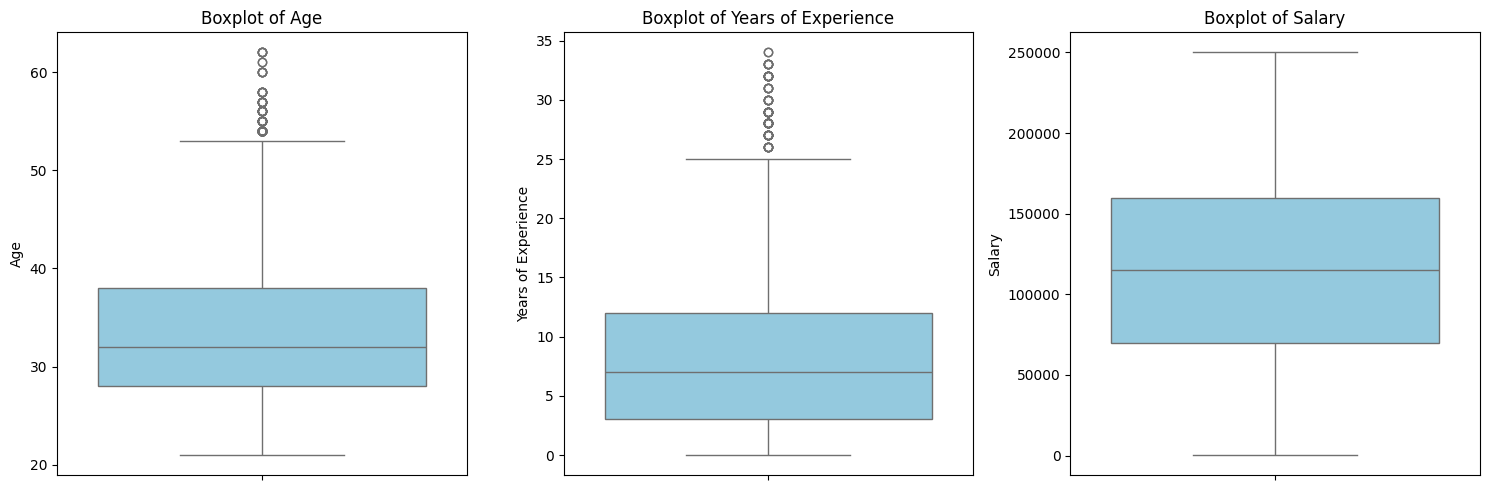


--- Outlier Detection Summary ---


,IQR Outliers Count,Z-score Outliers Count,Lower Bound (IQR),Upper Bound (IQR)
Age,123.0,28.0,13.0,53.0
Years of Experience,75.0,68.0,-10.5,25.5
Salary,0.0,0.0,-65000.0,295000.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Duplicate detection
duplicates_count = df.duplicated().sum()
print(f"Total duplicate rows detected: {duplicates_count}")

# 2. Missing data pattern analysis
missing_stats = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Values': missing_stats, 'Percentage (%)': missing_pct})
print("\n--- Missing Data Pattern Analysis ---")
display(missing_report)

# 3. Outlier detection using IQR and Z-Score
outlier_summary = {}
plt.figure(figsize=(15, 5))

for idx, col in enumerate(num_cols):
    if col in df.columns:
        col_clean = df[col].dropna()

        # IQR method
        q1 = col_clean.quantile(0.25)
        q3 = col_clean.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        iqr_outliers = col_clean[(col_clean < lower_bound) | (col_clean > upper_bound)]

        # Z-score method
        z_scores = np.abs(stats.zscore(col_clean))
        z_outliers = col_clean[z_scores > 3]

        outlier_summary[col] = {
            "IQR Outliers Count": len(iqr_outliers),
            "Z-score Outliers Count": len(z_outliers),
            "Lower Bound (IQR)": lower_bound,
            "Upper Bound (IQR)": upper_bound
        }

        # Visualize
        plt.subplot(1, 3, idx + 1)
        sns.boxplot(y=df[col], color='skyblue')
        plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

print("\n--- Outlier Detection Summary ---")
display(pd.DataFrame(outlier_summary).T)

### CELL 2: OUTLIER INVESTIGATION
This cell filters and isolates extreme records where numerical columns fall outside normal statistical boundaries (e.g., extremely high/low salaries or years of experience) to assist with business decision-making.

In [ ]:
print("--- Detailed Investigation of Outliers (using IQR boundaries) ---")

outlier_indices = set()
for col in num_cols:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Get indices of outliers
        cond = (df[col] < lower_bound) | (df[col] > upper_bound)
        outliers_df = df[cond]
        outlier_indices.update(outliers_df.index)

        print(f"\nOutliers detected in {col} (Count: {len(outliers_df)}):")
        if not outliers_df.empty:
            display(outliers_df.head(10))
        else:
            print("No outliers found for this variable.")

print(f"\nTotal unique rows affected by outliers in any numerical column: {len(outlier_indices)}")

--- Detailed Investigation of Outliers (using IQR boundaries) ---

Outliers detected in Age (Count: 123):


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1211,61.0,Male,PhD,Software Engineer Manager,20.0,200000.0
1223,57.0,Male,PhD,Software Engineer Manager,18.0,195000.0
1225,62.0,Male,PhD,Software Engineer Manager,19.0,200000.0
1236,62.0,Male,PhD,Software Engineer Manager,20.0,200000.0
1240,55.0,Male,PhD,Software Engineer Manager,17.0,190000.0
1246,56.0,Male,PhD,Software Engineer Manager,17.0,195000.0
1258,62.0,Male,PhD,Software Engineer Manager,19.0,200000.0
1259,54.0,Male,PhD,Software Engineer Manager,17.0,195000.0
1260,60.0,Male,PhD,Software Engineer Manager,18.0,195000.0
1261,54.0,Female,PhD,Software Engineer Manager,14.0,190000.0



Outliers detected in Years of Experience (Count: 75):


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
2378,53.0,Other,High School,Senior Project Engineer,31.0,166109.0
2387,57.0,Female,PhD,Full Stack Engineer,30.0,121450.0
2392,52.0,Female,Master's Degree,Senior Software Engineer,28.0,186963.0
2396,60.0,Female,PhD,Software Engineer Manager,33.0,179180.0
2398,58.0,Male,Master's Degree,Senior Software Engineer,27.0,190004.0
2401,57.0,Female,PhD,Software Engineer Manager,33.0,191790.0
2421,60.0,Female,PhD,Software Engineer Manager,34.0,188651.0
2423,55.0,Male,Bachelor's Degree,Senior Project Engineer,28.0,193964.0
2435,57.0,Female,Master's Degree,Full Stack Engineer,33.0,188232.0
2437,54.0,Male,PhD,Software Engineer Manager,28.0,188484.0



Outliers detected in Salary (Count: 0):
No outliers found for this variable.

Total unique rows affected by outliers in any numerical column: 148


### CELL 3: OUTLIER TREATMENT DECISIONS
Here we establish a business-logic based capping threshold (Winsorization) to handle extreme values without discarding critical data points.

In [ ]:
df_treated = df.copy()

print("--- Outlier Treatment (Capping / Winsorization) ---")
for col in num_cols:
    if col in df_treated.columns:
        q1 = df_treated[col].quantile(0.25)
        q3 = df_treated[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Cap outliers to lower/upper bound
        df_treated[col] = np.clip(df_treated[col], lower_bound, upper_bound)
        print(f"Capped values in '{col}' to range [{lower_bound:.2f}, {upper_bound:.2f}]")

print("\nOutlier treatment successfully documented and applied.")

--- Outlier Treatment (Capping / Winsorization) ---
Capped values in 'Age' to range [13.00, 53.00]
Capped values in 'Years of Experience' to range [-10.50, 25.50]
Capped values in 'Salary' to range [-65000.00, 295000.00]

Outlier treatment successfully documented and applied.


### CELL 4: MISSING DATA HANDLING
We handle missing values automatically. Numerical columns are imputed with their median value to avoid skewness, and categorical columns are filled with the column's statistical mode.

In [ ]:
print("--- Imputation of Missing Values ---")

# Impute numerical columns with median
for col in num_cols:
    if col in df_treated.columns:
        median_val = df_treated[col].median()
        missing_count = df_treated[col].isnull().sum()
        df_treated[col] = df_treated[col].fillna(median_val)
        print(f"Imputed {missing_count} missing values in '{col}' with median: {median_val}")

# Impute categorical columns with mode
for col in cat_cols:
    if col in df_treated.columns:
        mode_val = df_treated[col].mode()[0]
        missing_count = df_treated[col].isnull().sum()
        df_treated[col] = df_treated[col].fillna(mode_val)
        print(f"Imputed {missing_count} missing values in '{col}' with mode: {mode_val}")

--- Imputation of Missing Values ---
Imputed 2 missing values in 'Age' with median: 32.0
Imputed 3 missing values in 'Years of Experience' with median: 7.0
Imputed 5 missing values in 'Salary' with median: 115000.0
Imputed 2 missing values in 'Gender' with mode: Male
Imputed 3 missing values in 'Education Level' with mode: Bachelor's Degree
Imputed 2 missing values in 'Job Title' with mode: Software Engineer


### CELL 5: DATA TYPE OPTIMIZATION & STANDARDIZATION
This section eliminates exact duplicate records, normalizes job title text inputs (trimming whitespaces, converting to consistent case formatting), and performs min-max normalization on key scale parameters.

In [ ]:
# 1. Remove duplicate records
before_dedup = len(df_treated)
df_treated = df_treated.drop_duplicates()
after_dedup = len(df_treated)
print(f"Removed {before_dedup - after_dedup} exact duplicate rows.\n")

# 2. Standardize text strings in categories
for col in cat_cols:
    if col in df_treated.columns:
        # Convert to string, strip whitespace, uniform title case
        df_treated[col] = df_treated[col].astype(str).str.strip().str.title().astype('category')
print("Categorical text formatting standardized to Title Case.")

# 3. Min-Max Normalization of Numerical Columns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_cols = [f'{col}_normalized' for col in num_cols]
df_treated[scaled_cols] = scaler.fit_transform(df_treated[num_cols])
print("\nNumerical columns normalized using MinMaxScaler. Preview of normalized columns:")
display(df_treated[scaled_cols].head())

Removed 4919 exact duplicate rows.

Categorical text formatting standardized to Title Case.

Numerical columns normalized using MinMaxScaler. Preview of normalized columns:


,Age_normalized,Years of Experience_normalized,Salary_normalized
0,0.34375,0.196078,0.359103
1,0.21875,0.117647,0.258963
2,0.75000,0.588235,0.599439
3,0.46875,0.274510,0.238935
4,0.96875,0.784314,0.799720


### CELL 6: CLEANED DATA VALIDATION
Finally, we evaluate the before-and-after states of the data frame to guarantee absolute consistency, verify outlier removal, and export the file for subsequent trend modeling.

In [ ]:
print("--- Final Validation Report ---")
print(f"Original shape: {df.shape} | Cleaned & De-duplicated shape: {df_treated.shape}")
print(f"Missing values remaining: {df_treated.isnull().sum().sum()}")

# Display cleaned overview
print("\n--- Cleaned DataFrame Sample Overview ---")
display(df_treated.head(10))

# Export option
cleaned_filename = 'Cleaned_Salary_Data.csv'
df_treated.to_csv(cleaned_filename, index=False)
print(f"\nCleaned and standardized dataset successfully exported to '{cleaned_filename}'!")

--- Final Validation Report ---
Original shape: (6704, 6) | Cleaned & De-duplicated shape: (1785, 9)
Missing values remaining: 0

--- Cleaned DataFrame Sample Overview ---


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Age_normalized,Years of Experience_normalized,Salary_normalized
0,32.0,Male,Bachelor'S,Software Engineer,5.0,90000.0,0.34375,0.196078,0.359103
1,28.0,Female,Master'S,Data Analyst,3.0,65000.0,0.21875,0.117647,0.258963
2,45.0,Male,Phd,Senior Manager,15.0,150000.0,0.75000,0.588235,0.599439
3,36.0,Female,Bachelor'S,Sales Associate,7.0,60000.0,0.46875,0.274510,0.238935
4,52.0,Male,Master'S,Director,20.0,200000.0,0.96875,0.784314,0.799720
5,29.0,Male,Bachelor'S,Marketing Analyst,2.0,55000.0,0.25000,0.078431,0.218906
6,42.0,Female,Master'S,Product Manager,12.0,120000.0,0.65625,0.470588,0.479271
7,31.0,Male,Bachelor'S,Sales Manager,4.0,80000.0,0.31250,0.156863,0.319047
8,26.0,Female,Bachelor'S,Marketing Coordinator,1.0,45000.0,0.15625,0.039216,0.178850
9,38.0,Male,Phd,Senior Scientist,10.0,110000.0,0.53125,0.392157,0.439215



Cleaned and standardized dataset successfully exported to 'Cleaned_Salary_Data.csv'!


### PHASE 1: UNIVARIATE ANALYSIS
In this phase, we analyze the distribution of each numerical column (Age, Years of Experience, and Salary) and the frequency of categorical variables (Gender, Education Level, and Job Title) within our clean dataset.

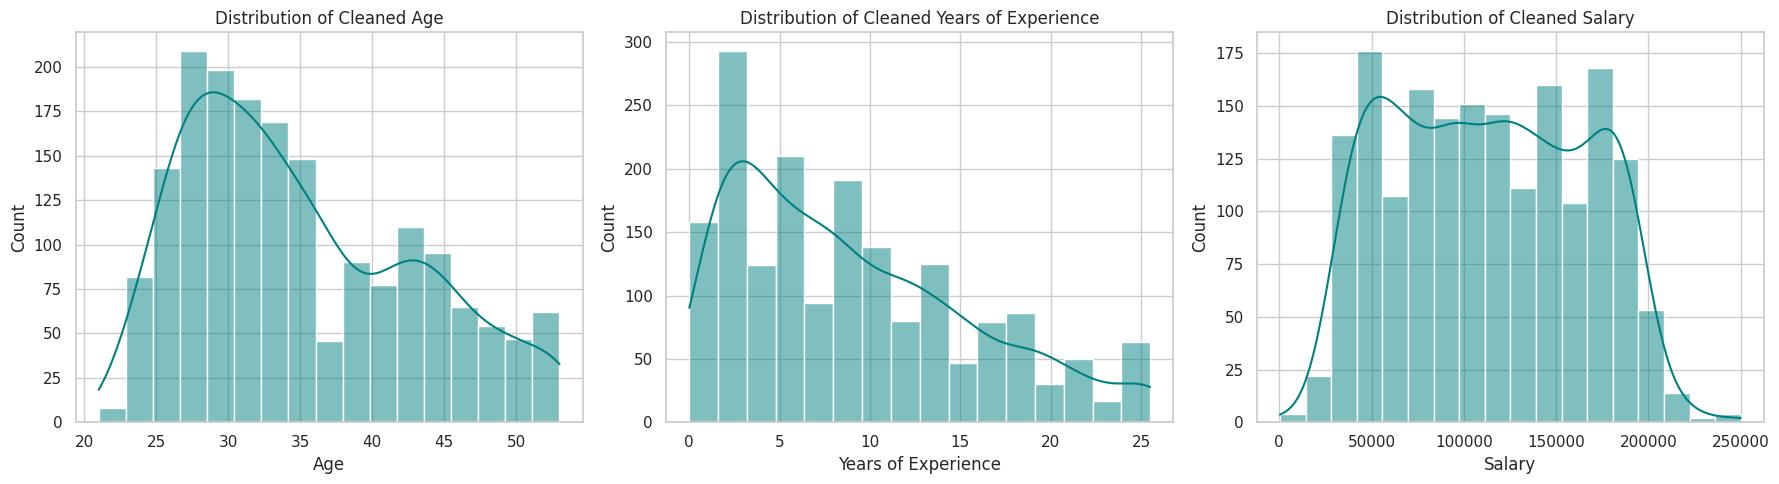

/tmp/ipykernel_2804/4052470889.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_treated, x='Gender', ax=axes[0], palette='pastel')
/tmp/ipykernel_2804/4052470889.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_treated, y='Education Level', ax=axes[1], palette='pastel', order=df_treated['Education Level'].value_counts().index)


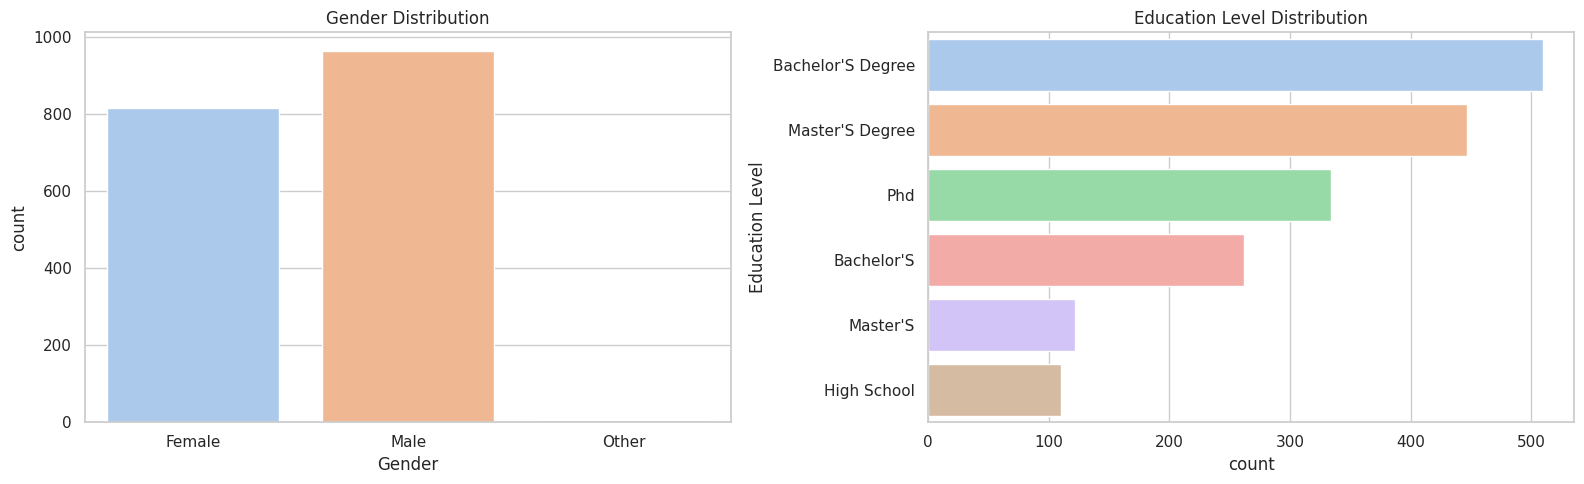

/tmp/ipykernel_2804/4052470889.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_treated, y='Job Title', palette='viridis', order=df_treated['Job Title'].value_counts().head(10).index)


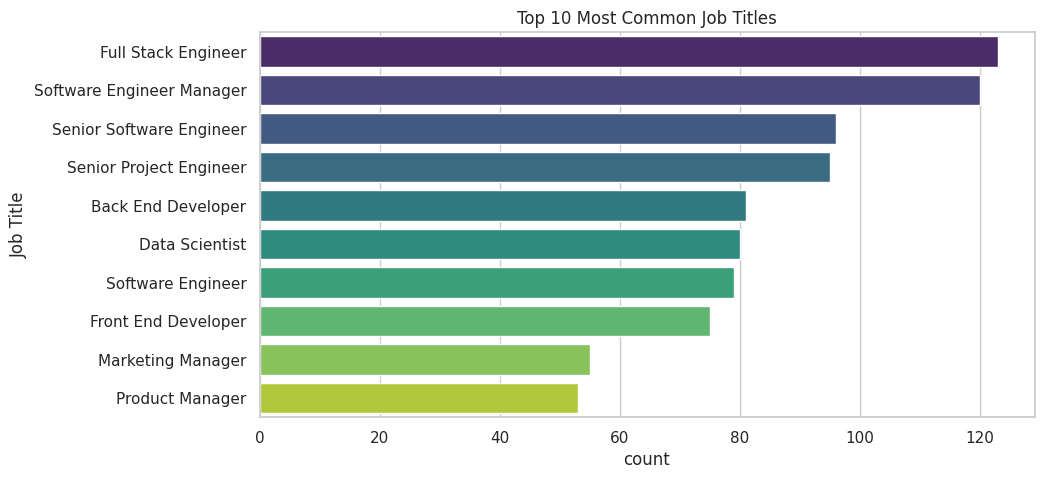


--- Cleaned Dataset Summary Statistics ---


,Age,Years of Experience,Salary
count,1785.000000,1785.000000,1785.000000
mean,34.980392,9.033613,112857.695798
std,7.953914,6.596387,51365.822001
min,21.000000,0.000000,350.000000
25%,29.000000,3.000000,70000.000000
50%,33.000000,8.000000,110000.000000
75%,41.000000,13.000000,158966.000000
max,53.000000,25.500000,250000.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# 1. Distribution of Numerical Columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(num_cols):
    sns.histplot(df_treated[col], kde=True, ax=axes[idx], color='teal')
    axes[idx].set_title(f'Distribution of Cleaned {col}')
plt.tight_layout()
plt.show()

# 2. Frequency Analysis of Key Categorical Columns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df_treated, x='Gender', ax=axes[0], palette='pastel')
axes[0].set_title('Gender Distribution')

# Show top 10 Education Levels
sns.countplot(data=df_treated, y='Education Level', ax=axes[1], palette='pastel', order=df_treated['Education Level'].value_counts().index)
axes[1].set_title('Education Level Distribution')
plt.tight_layout()
plt.show()

# 3. Frequency Analysis of Top Job Titles
plt.figure(figsize=(10, 5))
sns.countplot(data=df_treated, y='Job Title', palette='viridis', order=df_treated['Job Title'].value_counts().head(10).index)
plt.title('Top 10 Most Common Job Titles')
plt.show()

# Summary Statistics
print("\n--- Cleaned Dataset Summary Statistics ---")
display(df_treated[num_cols].describe())

### PHASE 2: BIVARIATE ANALYSIS
Here, we explore relationships between pairs of variables. This includes examining how Age and Experience relate to Salary, and visualizing how Salary shifts across different categories like Gender or Education Level without outlier noise.

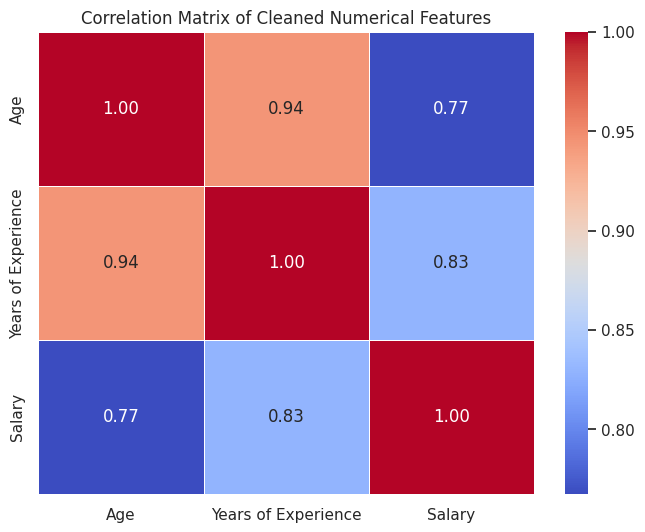

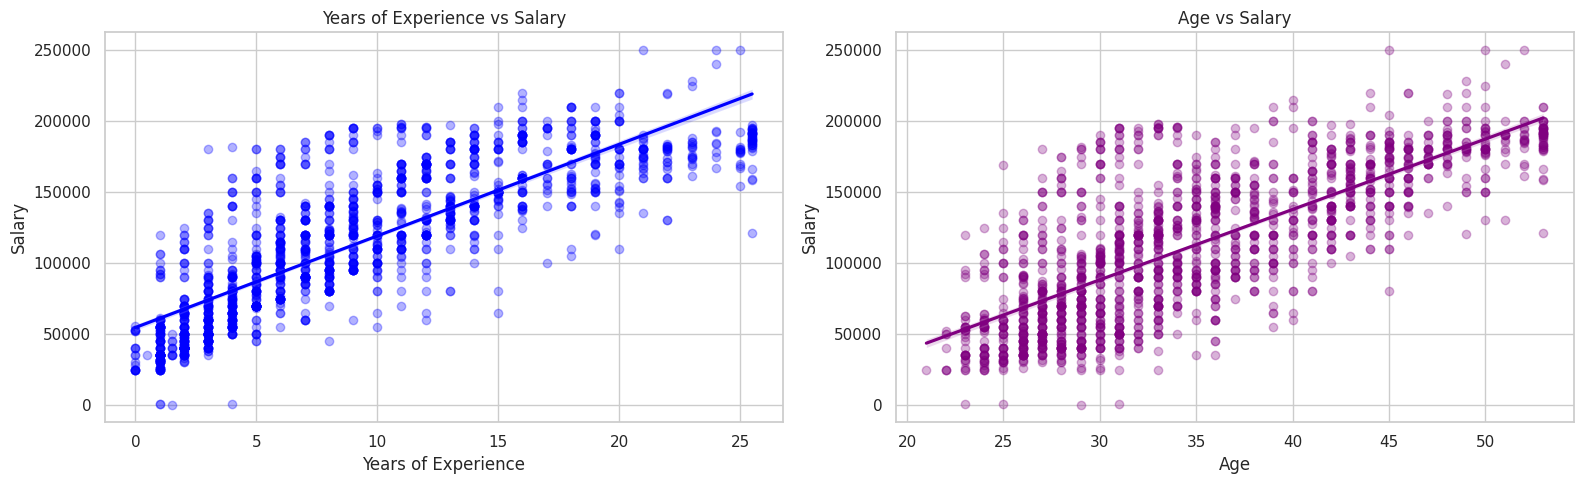

/tmp/ipykernel_2804/3414958877.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_treated, x='Gender', y='Salary', ax=axes[0], palette='Set2')
/tmp/ipykernel_2804/3414958877.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_treated, x='Salary', y='Education Level', ax=axes[1], palette='Set2')


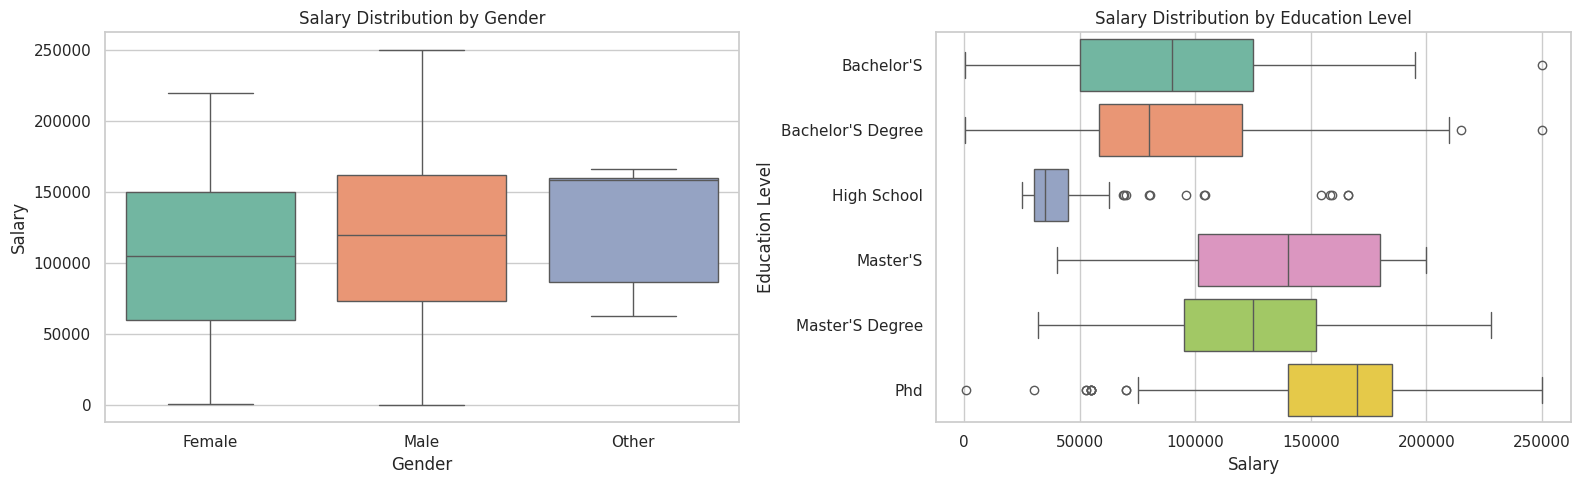

In [ ]:
# 1. Correlation Matrix between Numerical Variables
plt.figure(figsize=(8, 6))
corr_matrix = df_treated[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Cleaned Numerical Features')
plt.show()

# 2. Scatter Plots with Regression Lines
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.regplot(data=df_treated, x='Years of Experience', y='Salary', ax=axes[0], color='blue', scatter_kws={'alpha':0.3})
axes[0].set_title('Years of Experience vs Salary')

sns.regplot(data=df_treated, x='Age', y='Salary', ax=axes[1], color='purple', scatter_kws={'alpha':0.3})
axes[1].set_title('Age vs Salary')
plt.tight_layout()
plt.show()

# 3. Categorical Comparisons with Salary
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df_treated, x='Gender', y='Salary', ax=axes[0], palette='Set2')
axes[0].set_title('Salary Distribution by Gender')

sns.boxplot(data=df_treated, x='Salary', y='Education Level', ax=axes[1], palette='Set2')
axes[1].set_title('Salary Distribution by Education Level')
plt.tight_layout()
plt.show()

### PHASE 3: MULTIVARIATE ANALYSIS
In this phase, we analyze multi-variable interaction patterns. We look at how experience and education interact to impact salaries, and segment our data by multiple dimensions simultaneously.

/tmp/ipykernel_2804/3535522294.py:15: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



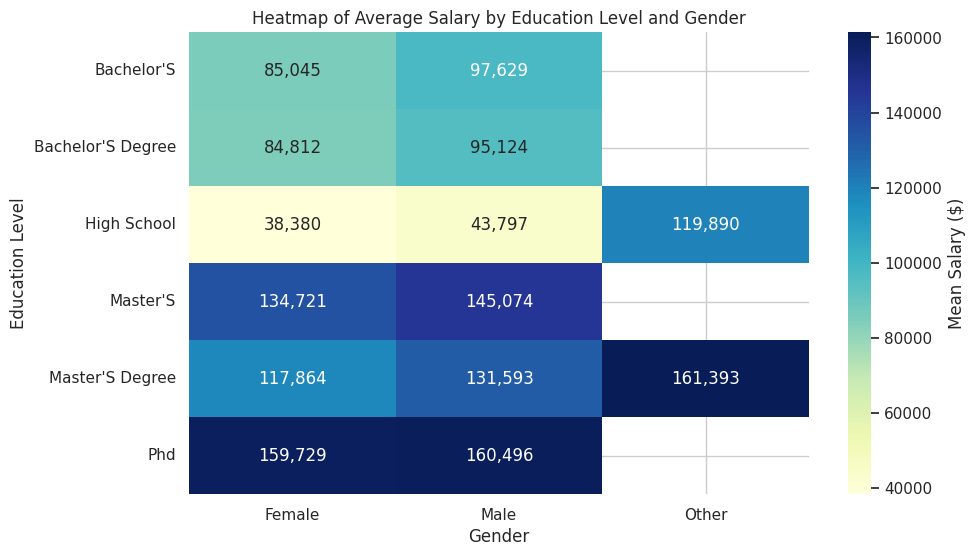

In [ ]:
# 1. Interactive Experience vs Salary segmented by Gender and Education
fig = px.scatter(
    df_treated,
    x="Years of Experience",
    y="Salary",
    color="Education Level",
    symbol="Gender",
    hover_data=['Age', 'Job Title'],
    title="Interactive Analysis: Experience vs Salary by Education and Gender"
)
fig.update_layout(width=900, height=600)
fig.show()

# 2. Average Salary Heatmap across Gender and Education Level
salary_pivot = df_treated.pivot_table(values='Salary', index='Education Level', columns='Gender', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(salary_pivot, annot=True, fmt=",.0f", cmap='YlGnBu', cbar_kws={'label': 'Mean Salary ($)'})
plt.title('Heatmap of Average Salary by Education Level and Gender')
plt.show()

### PHASE 4: BUSINESS INSIGHTS & STRATEGIC RECOMMENDATIONS
This cell computes specific analytical aggregations to answer key salary distribution questions, compares original stats with cleaned stats to verify the impact of outlier mitigation, and drafts structured findings.

In [ ]:
print("=== BUSINESS INSIGHTS AND DATA EVIDENCE ===")

# 1. Salary Premiums by Education
educ_stats = df_treated.groupby('Education Level')['Salary'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)
print("\n1. Pay Differentials by Education Level:")
display(educ_stats)

# 2. Gender Pay Disparities
gender_stats = df_treated.groupby('Gender')['Salary'].agg(['mean', 'median', 'count'])
print("\n2. Gender Pay Gap Metrics:")
display(gender_stats)

# 3. Pay Scale Evolution with Experience
# Segment experience into bins
df_treated['Experience Group'] = pd.cut(df_treated['Years of Experience'], bins=[-1, 2, 5, 10, 15, 20, 35],
                                         labels=['Entry (0-2 yrs)', 'Junior (3-5 yrs)', 'Mid (6-10 yrs)',
                                                 'Senior (11-15 yrs)', 'Lead (16-20 yrs)', 'Executive (21+ yrs)'])
exp_stats = df_treated.groupby('Experience Group', observed=False)['Salary'].agg(['mean', 'median', 'count'])
print("\n3. Career Level Progression metrics:")
display(exp_stats)

# 4. Outlier Impact Comparison
print("\n4. Statistical Comparison of Outlier Treatment:")
print(f"- Original Dataset Mean Age: {df['Age'].mean():.2f} years | Cleaned (Capped) Mean Age: {df_treated['Age'].mean():.2f} years")
print(f"- Original Max Experience: {df['Years of Experience'].max():.2f} years | Cleaned Max Experience: {df_treated['Years of Experience'].max():.2f} years")

=== BUSINESS INSIGHTS AND DATA EVIDENCE ===

1. Pay Differentials by Education Level:


/tmp/ipykernel_2804/3964337118.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,count
Education Level,,,
Phd,160213.772455,170000.0,334
Master'S,139303.278689,140000.0,122
Master'S Degree,124165.176734,125000.0,447
Bachelor'S,92249.427481,90000.0,262
Bachelor'S Degree,90736.166667,80000.0,510
High School,45435.981818,35000.0,110



2. Gender Pay Gap Metrics:


/tmp/ipykernel_2804/3964337118.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,count
Gender,,,
Female,107304.252761,105000.0,815
Male,117463.435099,120000.0,963
Other,125819.000000,158254.0,7



3. Career Level Progression metrics:


,mean,median,count
Experience Group,,,
Entry (0-2 yrs),48650.288026,43000.0,309
Junior (3-5 yrs),77341.251351,70000.0,370
Mid (6-10 yrs),115865.592998,110000.0,457
Senior (11-15 yrs),147325.867284,146917.0,324
Lead (16-20 yrs),171786.943590,170000.0,195
Executive (21+ yrs),181685.953846,181076.5,130



4. Statistical Comparison of Outlier Treatment:
- Original Dataset Mean Age: 33.62 years | Cleaned (Capped) Mean Age: 34.98 years
- Original Max Experience: 34.00 years | Cleaned Max Experience: 25.50 years
